In [2]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import START, END
from langgraph.graph.state import StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage

import os
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGCHAIN_PROJECT"] = os.getenv("LANGCHAIN_PROJECT")
os.environ["LANGCHAIN_TRACING_V2"] = os.getenv("LANGCHAIN_TRACING_V2", "true")


In [32]:
from langchain.chat_models import init_chat_model
llm = init_chat_model("gpt-4-0613", temperature=0)
llm

ChatOpenAI(output_version=None, client=<openai.resources.chat.completions.completions.Completions object at 0x1229e20f0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x1229e0230>, root_client=<openai.OpenAI object at 0x117e5a420>, root_async_client=<openai.AsyncOpenAI object at 0x1229e0260>, model_name='gpt-4-0613', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), openai_proxy=None, stream_usage=True, stream_chunk_timeout=120.0)

In [33]:
class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

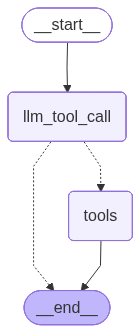

In [34]:
from langchain_core.tools import tool
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display

@tool
def add_numbers(a: int, b: int) -> int:
    """Add two numbers together."""
    return a + b

tools = [add_numbers]
tool_node = ToolNode([add_numbers])
llm_with_tool = llm.bind_tools([add_numbers])

def call_llm_with_tools(state: State) -> State:
    response = llm_with_tool.invoke(state["messages"])
    return {"messages": state["messages"] + [response]}

builder = StateGraph(State)

builder.add_node("llm_tool_call", call_llm_with_tools)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "llm_tool_call")
builder.add_conditional_edges(
    "llm_tool_call",
    tools_condition
)
builder.add_edge("tools", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


In [35]:
response = graph.invoke({"messages": "What is IPL"})
print(response["messages"][-1].content)

IPL stands for Indian Premier League. It is a professional Twenty20 cricket league in India, which is usually held between March and May of every year by eight teams representing eight different cities or states in India. The league was founded by the Board of Control for Cricket in India (BCCI) in 2007. It has become one of the most attended cricket league in the world and ranks sixth among all sports leagues globally.


In [36]:
response = graph.invoke({"messages": "What is 2 plus 2"})
print(response["messages"][-1].content)

4
